# Illustration on synthetic data of the impact of epistemic distinction for Anomaly considering uncertainty quantification.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import pickle
import os
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

from IPython.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))

# Generation of synthetic data with global & local anomaly and OOD behaviour

2025-12-05 15:47:49.193300: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-05 15:47:49.209978: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764949669.227545  392777 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764949669.232737  392777 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-05 15:47:49.251165: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

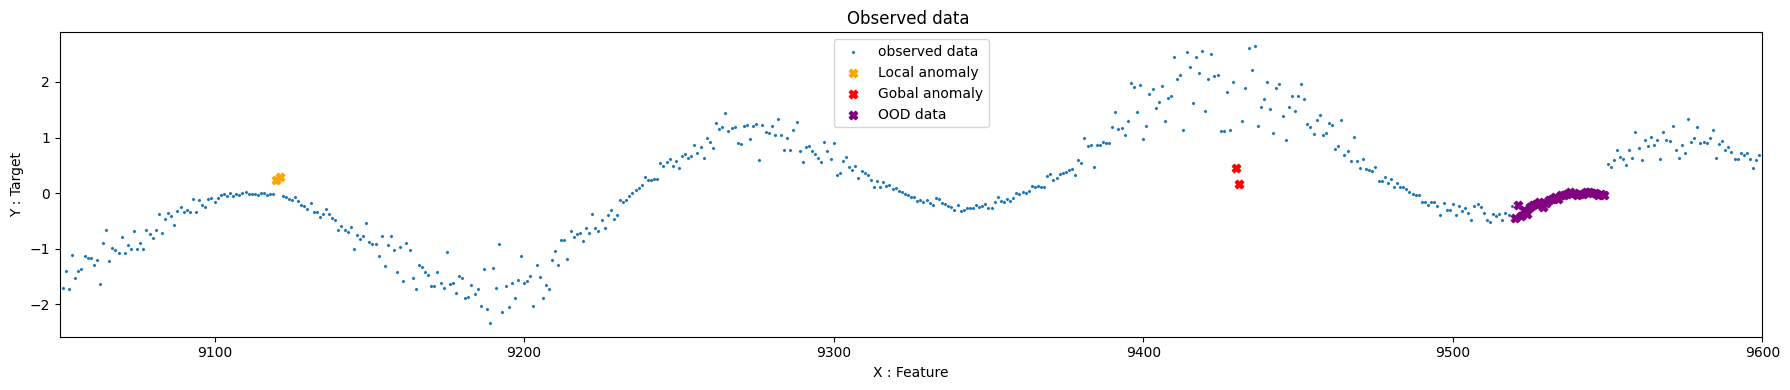

In [2]:
from uqmodels.utils import cut

# Generation of synthetic data

X = []
y_mean = []
std =[]
X_noise = []
Y_noise = []
state = []

N = 10000
n_mod = 1

#rng = np.random.RandomState(106)
rng = np.random.RandomState(109)

X = np.arange(0, 100,100/N)
r1 = rng.uniform(-0.3,0.3)
r2 = 4
y_mean = np.cos(X+r1) + np.cos(r2*X)
Y_noise = cut(rng.normal(0,1,N),0.02,0.98) * (0.02+np.abs(y_mean)/5)
std = np.abs(y_mean)
state = np.zeros(len(X))

y = y_mean+Y_noise
y_bis = np.copy(y)
y_bis[9520:9550] = y[9715:9745]
y_bis[-879] = y_bis[-879] + 0.3
y_bis[-880] = y_bis[-880] + 0.3
y_bis[-569] = y_bis[-569] - 2.2
y_bis[-570] = y_bis[-570] - 1.5

true_label = np.zeros((len(y),1))
true_label[-879] = 1
true_label[-880] = 1
true_label[-570] = 2
true_label[-569] = 2
true_label[9520:9550] = 3

y = y_bis.reshape(-1,1)


Datasets=[] # X,y,ctx,train,name
feature = X[:,None]
from sklearn.preprocessing import StandardScaler
from uqmodels.preprocessing.preprocessing import rolling_statistics

mean_var_50 = rolling_statistics(pd.DataFrame(np.roll(y,1)),50,1,['mean','std'],['mean','std']).replace(np.nan,0).values
mean_var_25 = rolling_statistics(pd.DataFrame(np.roll(y,1)),25,1,['mean','std'],['mean','std']).replace(np.nan,0).values
mean_var_20 = rolling_statistics(pd.DataFrame(np.roll(y,1)),10,1,['mean','std'],['mean','std']).replace(np.nan,0).values

features = np.concatenate([mean_var_20,mean_var_25,mean_var_50,np.array(X%(np.pi))[:,None],np.array(X%(r2*np.pi))[:,None]],axis=1)
features = StandardScaler().fit_transform(features)
Datasets.append([features,y,state,np.arange(10000)<7000,'Unnoised ML-task'])

X,y,ctx,train,name = Datasets[0]

test = np.invert(train)

f_obs = (np.arange(len(y))>9050) & (np.arange(len(y))<9600)
plt.figure(figsize=(18,4))
plt.title('Observed data ')
plt.scatter(np.arange(len(X))[f_obs],y[f_obs],s=2,marker="x",label='observed data')
plt.xlabel('X : Feature')
plt.ylabel('Y : Target')
mask_anom_1 = true_label[:,0]==1
mask_anom_2 = true_label[:,0]==2
mask_anom_3 = true_label[:,0]==3
plt.scatter(np.arange(len(X))[mask_anom_1&f_obs],y[mask_anom_1&f_obs],color='orange',marker='X',label='Local anomaly')
plt.scatter(np.arange(len(X))[mask_anom_2&f_obs],y[mask_anom_2&f_obs],color='red',marker='X',label='Gobal anomaly')
plt.scatter(np.arange(len(X))[mask_anom_3&f_obs],y[mask_anom_3&f_obs],color='purple',marker='X',label='OOD data')
plt.legend(loc=9)
plt.xlim(9050,9600)
plt.tight_layout()
plt.show()


In [3]:
# Train and inference of and UQModels based on a Random forest regressor UQ-estimators

from uqmodels.modelization.ML_estimator.random_forest_UQ import RF_UQEstimator,get_params_dict
from uqmodels.custom_UQModel import UQModel_KPI
# We can also create a more complexe UQmodel that hanUQKPI_ProcessorPI_Processor to build at inference (UQMesure, Predictive interval and model unreliability score) and after observation (Anomaly score)

# Specification of the UQestimator & Instanciation in a UQmodels wrapper that include post-processing
RF_UQ_paramaters = get_params_dict(var_min=0.00001,type_UQ='var_A&E',rescale=True,
                                   ccp_alpha=1e-06, max_depth=15, max_features=0.9,
                                   max_samples=0.9, min_impurity_decrease=0.00001,
                                   min_samples_leaf=8,min_samples_split=8, n_estimators=125,random_state=0)

RF_UQModel = UQModel_KPI(RF_UQEstimator,
                         RF_UQ_paramaters,
                         name='UQModels',
                         reduc_filter_KPI = None,
                         reduc_filter_pred= None,
                         anom_with_born=True,
                         cache_manager=None)

RF_UQModel.list_score_KPI_processors[1].KPI_parameters = {'beta': 0.001,'type_norm':'Nsigma_global','with_born': True,'d':2, 'reduc_filter': None,'q_var':1,'q_var_e':1,'k_var_e':1,'q_Eratio':3,'filt':[0.05,0.15,0.8,0,0]}

RF_UQModel.fit(X[train],y[train])
pred,((_,UQ),PIs,Elvl) = RF_UQModel.predict(X,y)
(pred,UQ),(KPI_anom,born_model),PIs,Escore = RF_UQModel.score(X,y)

from uqmodels.evaluation.metrics import Generic_metric, rmse, UQ_average_coverage, UQ_sharpness, UQ_Gaussian_NLL, UQ_dEI, UQ_absolute_residu_score
from uqmodels.evaluation.evaluation import evaluate

if(True):
    list_metrics=[Generic_metric(rmse,'Root mean square',mask=None,list_ctx_constraint=None,reduce=False,type_UQ='var_A&E'),
                  Generic_metric(UQ_average_coverage,'Root mean square',mask=None,list_ctx_constraint=None,reduce=False,type_UQ='var_A&E')]
    output = pred,UQ
    metrics_val = evaluate(y,output,list_metrics,list_sets=[train,test],verbose=True)

Root mean square [array([0.15826065]), array([0.22641012])]
Root mean square [array([0.99842857]), array([0.954])]


target [0.025, 0.16, 0.84, 0.975] empirique [0.008, 0.1085, 0.8859, 0.9914]
target elvl [0.5, 0.8, 0.95, 0.98, 0.995, 1] empirique Elvl [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]


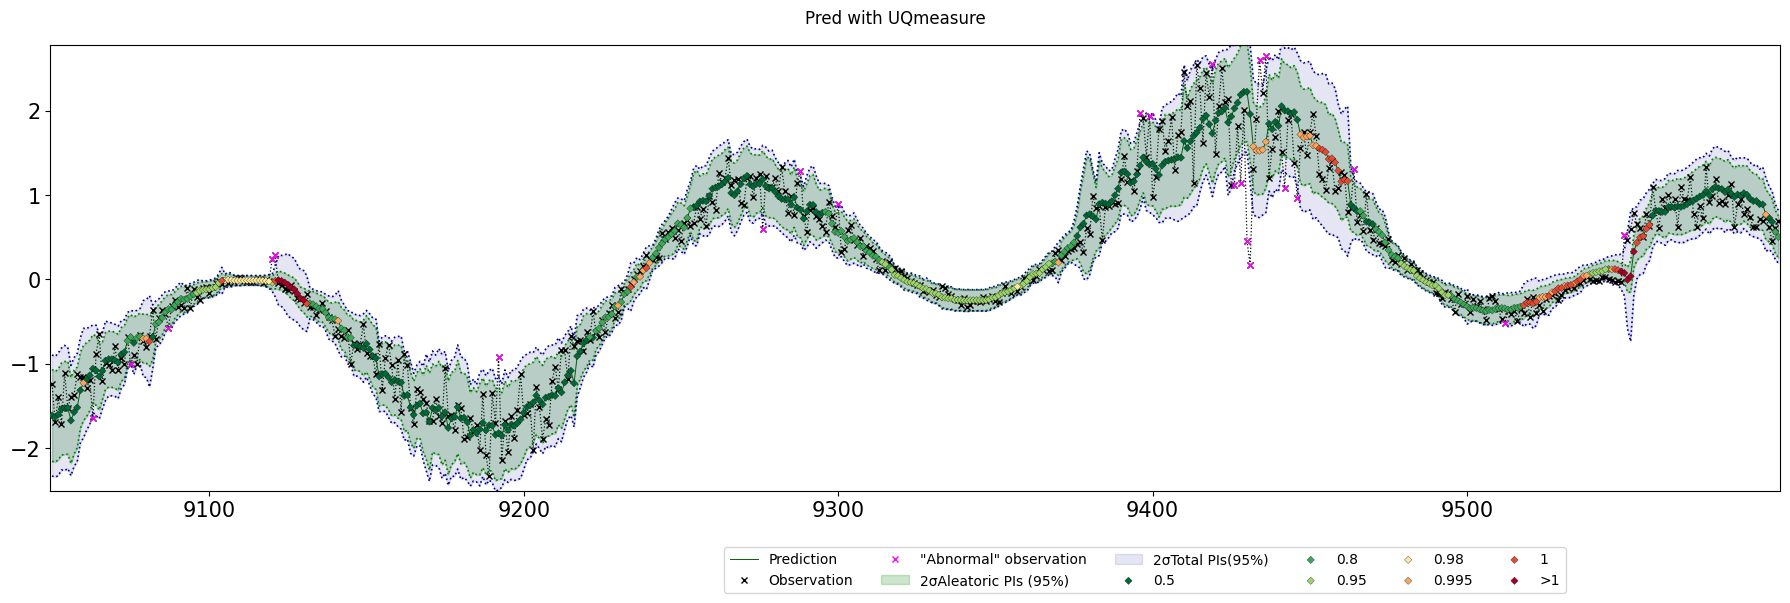

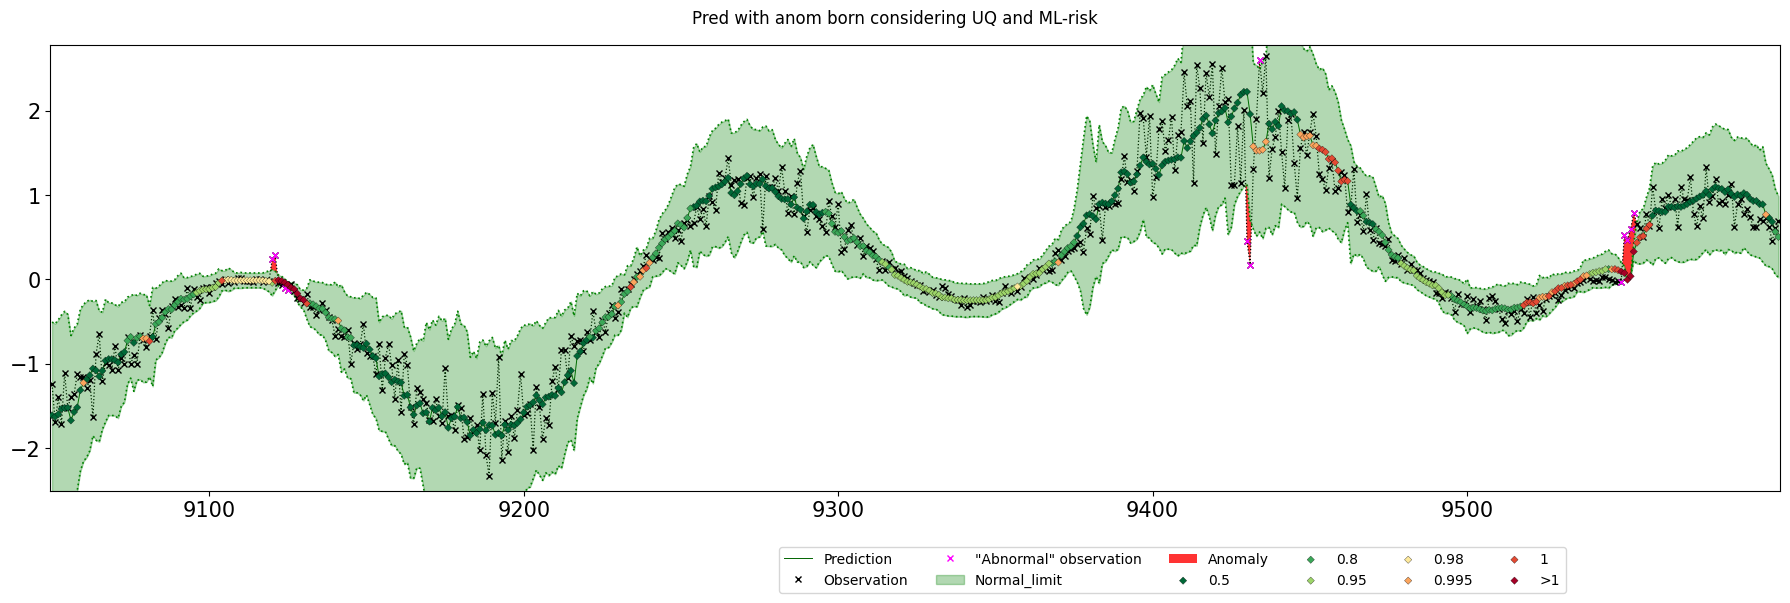

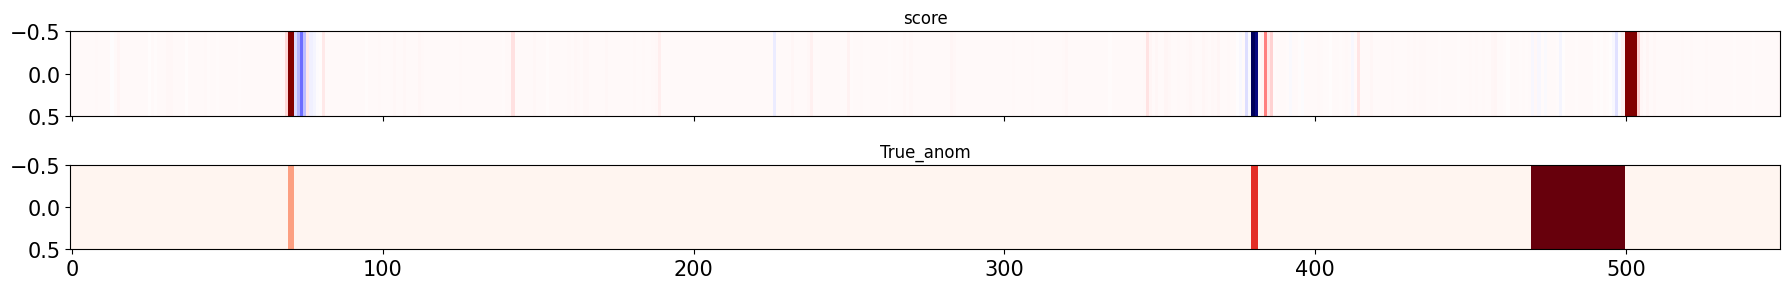

b_no_UQ 0.001 0.001
b_no_UQ_with_e 0.001 0.001
b_UQ 0.001 0.001
b_e 0.001 0.001


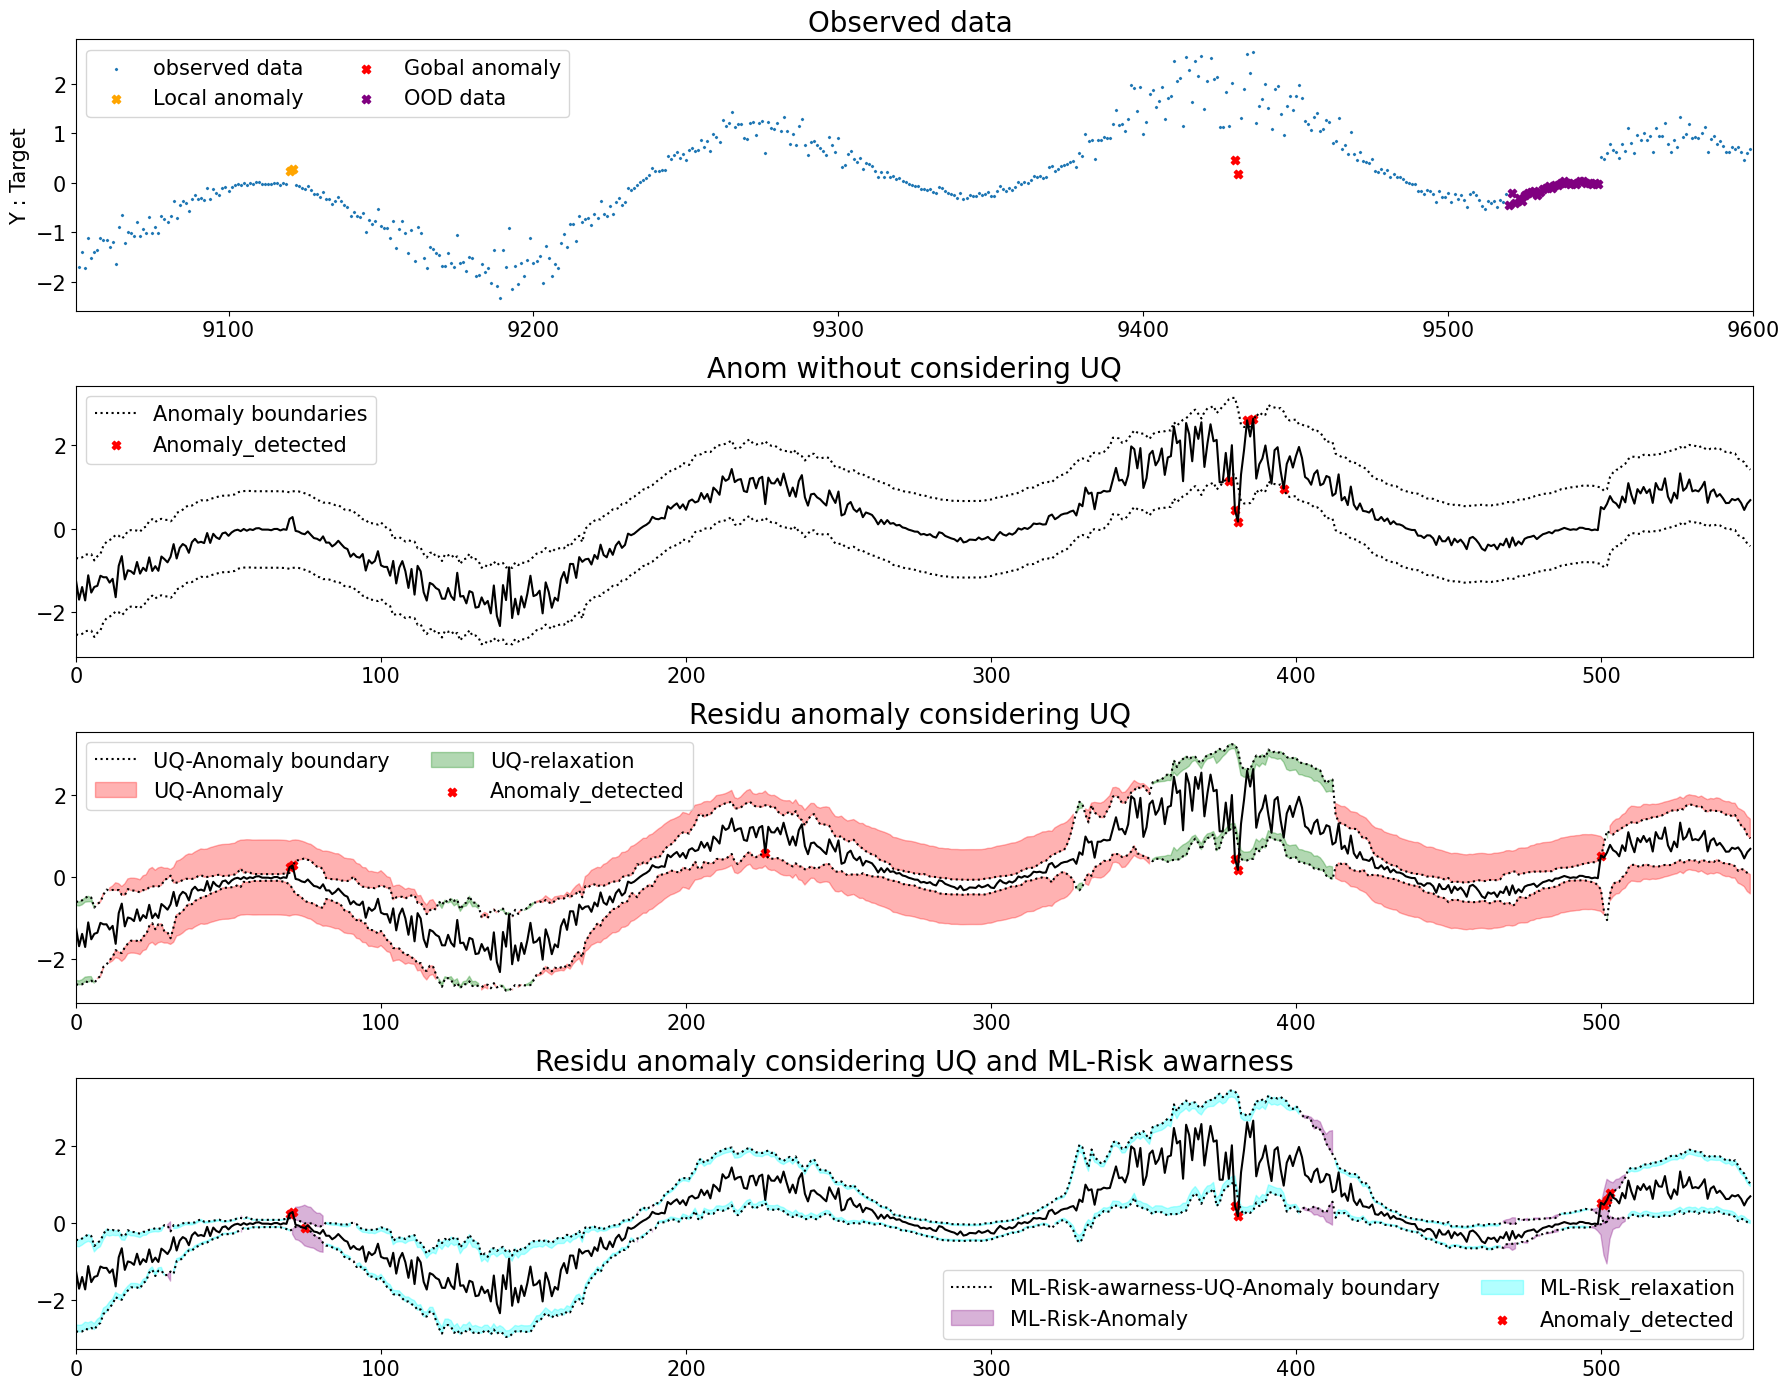

In [4]:
%matplotlib notebook
%matplotlib inline
import matplotlib.pyplot as plt
import uqmodels.visualization.visualization as visu


list_alpha = RF_UQModel.list_predict_KPI_processors[1].KPI_parameters['list_alpha']
print('target', list_alpha, 'empirique', [(pi>y).mean() for pi in PIs])
list_percent =RF_UQModel.list_predict_KPI_processors[2].KPI_parameters['list_percent']
print('target elvl',list_percent,'empirique Elvl',[np.quantile(Elvl,q) for q in list_percent])

f_obs = np.arange(len(y))[-950:-400]
visu.uncertainty_plot(y,output,context=None,size=(18,6),f_obs=f_obs,name='Pred with UQmeasure',mode_res=False,dim=np.arange(y.shape[1]),confidence_lvl=Elvl,type_UQ='var_A&E',list_percent=list_percent)
visu.uncertainty_plot(y,output,context=None,size=(18,6),f_obs=f_obs,name='Pred with anom born considering UQ and ML-risk',mode_res=False,dim=np.arange(y.shape[1]),confidence_lvl=Elvl,type_UQ='var_A&E',born=born_model,list_percent=list_percent)
visu.plot_anom_matrice(score=KPI_anom,true_label=true_label,f_obs=f_obs,figsize=(18,3))

from uqmodels.postprocessing.anomaly_processing import fit_anom_score,compute_anom_score
from uqmodels.postprocessing.UQ_processing import process_UQmeasure_to_Epistemicscore
from uqmodels.utils import propagate

pred_ = pred*0
f_obs = np.arange(9050,9600)
x = np.arange(len(f_obs))

escore = process_UQmeasure_to_Epistemicscore(UQ=UQ,type_UQ='var_A&E',pred=pred,y=y)
params_anom = {'type_norm':'quantiles_local','with_born':True,'d':2,'beta':0.001,'q_var':0,'k_var_e':0}

params_ = fit_anom_score(UQ[:,train],'var_A&E',pred[train],y[train],**params_anom)
(res,born),_ = compute_anom_score(UQ,'var_A&E',pred,y,**params_anom)
print('b_no_UQ',((born[0] > y) | (born[1] < y)).mean(),(np.abs(res)>1).mean())

y_ = y[f_obs]-pred_[f_obs]
born_row = born[0]-pred_,born[1]-pred_
params_anom = {'type_norm':'quantiles_local','with_born':True,'d':2,'beta':0.001,'q_var':0,'q_var_e':1,'k_var_e':4,'q_Eratio':2}
params_ = fit_anom_score(UQ[:,train],'var_A&E',pred[train],y[train],**params_anom)
(res_e,born_e),_ = compute_anom_score(UQ,'var_A&E',pred,y,**params_anom)
print('b_no_UQ_with_e',((born_e[0] > y) | (born_e[1] < y)).mean(),(np.abs(res_e)>1).mean())
born_e = born_e[0]-pred_,born_e[1]-pred_

plt.figure(figsize=(18,14))

plt.subplot(4,1,1)
f_obs_bis = (np.arange(len(y))>9050) & (np.arange(len(y))<9600)
plt.title('Observed data ',fontsize=20)
plt.scatter(np.arange(len(X))[f_obs_bis],y[f_obs_bis],s=2,marker="x",label='observed data')
plt.ylabel('Y : Target')
mask_anom_1 = true_label[:,0]==1
mask_anom_2 = true_label[:,0]==2
mask_anom_3 = true_label[:,0]==3
plt.scatter(np.arange(len(X))[mask_anom_1&f_obs_bis],y[mask_anom_1&f_obs_bis],color='orange',marker='X',label='Local anomaly')
plt.scatter(np.arange(len(X))[mask_anom_2&f_obs_bis],y[mask_anom_2&f_obs_bis],color='red',marker='X',label='Gobal anomaly')
plt.scatter(np.arange(len(X))[mask_anom_3&f_obs_bis],y[mask_anom_3&f_obs_bis],color='purple',marker='X',label='OOD data')
plt.legend(ncol=2,fontsize=15)
plt.xlim(9050,9600)

plt.subplot(4,1,2)
plt.title('Anom without considering UQ',fontsize=20)
plt.plot(y_,color='black')
plt.plot(born_row[0][f_obs],color='black',ls=':',label='Anomaly boundaries')
plt.plot(born_row[1][f_obs],color='black',ls=':')
mask_anom = ((y_ <  born_row[0][f_obs])|(y_ >  born_row[1][f_obs])).reshape(-1)
plt.scatter(x[mask_anom],y_[mask_anom],color='red',marker='X',label='Anomaly_detected')
plt.legend()
plt.xlim(0,550)

params_anom = {'type_norm':'quantiles_local','with_born':True,'d':2,'beta':0.001,'q_var':1,'q_var_e':0,'k_var_e':0,'q_Eratio':0}
params_ = fit_anom_score(UQ[:,train],'var_A&E',pred[train],y[train],**params_anom)
(res,born),_ = compute_anom_score(UQ,'var_A&E',pred,y,**params_anom)
print('b_UQ',((born[0] > y) | (born[1] < y)).mean(),(np.abs(res)>1).mean())
born_UQ = born[0]-pred_,born[1]-pred_

params_anom = {'type_norm':'quantiles_local','with_born':True,'d':2,'beta':0.001,'q_var':1,'q_var_e':1,'k_var_e':1,'q_Eratio':3}
params_ = fit_anom_score(UQ[:,train],'var_A&E',pred[train],y[train],**params_anom)
(res_e,born_e),_ = compute_anom_score(UQ,'var_A&E',pred,y,**params_anom)
print('b_e',((born_e[0] > y) | (born_e[1] < y)).mean(),(np.abs(res_e)>1).mean())
born_e = born_e[0]-pred_,born_e[1]-pred_

plt.subplot(4,1,3)
plt.title('Residu anomaly considering UQ ',fontsize=20)
plt.plot(y_,color='black')
plt.plot(born_UQ[0][f_obs],color='black',ls=':',label='UQ-Anomaly boundary')
plt.plot(born_UQ[1][f_obs],color='black',ls=':')
plt.fill_between(x,born_UQ[1][f_obs,0],born_row[1][f_obs,0],where=born_UQ[1][f_obs,0]<born_row[1][f_obs,0],color='red',alpha=0.3,label='UQ-Anomaly')
plt.fill_between(x,born_UQ[1][f_obs,0],born_row[1][f_obs,0],where=born_UQ[1][f_obs,0]>born_row[1][f_obs,0],color='green',alpha=0.3,label='UQ-relaxation')
plt.fill_between(x,born_UQ[0][f_obs,0],born_row[0][f_obs,0],where=born_UQ[0][f_obs,0]>born_row[0][f_obs,0],color='red',alpha=0.3)
plt.fill_between(x,born_UQ[0][f_obs,0],born_row[0][f_obs,0],where=born_UQ[0][f_obs,0]<born_row[0][f_obs,0],color='green',alpha=0.3)
mask_anom = ((y_ <  born_UQ[0][f_obs])|(y_ >  born_UQ[1][f_obs])).reshape(-1)
plt.scatter(x[mask_anom],y_[mask_anom],color='red',marker='X',label='Anomaly_detected')
plt.legend(ncol=2,fontsize=15)
plt.xlim(0,550)

plt.subplot(4,1,4)
plt.title('Residu anomaly considering UQ and ML-Risk awarness',fontsize=20)
plt.plot(y_,color='black')
plt.plot(born_e[0][f_obs],color='black',ls=':',label='ML-Risk-awarness-UQ-Anomaly boundary')
plt.plot(born_e[1][f_obs],color='black',ls=':')
plt.fill_between(x,born_e[1][f_obs,0],born_UQ[1][f_obs,0],where=born_e[1][f_obs,0]<born_UQ[1][f_obs,0],color='purple',alpha=0.3,label='ML-Risk-Anomaly')
plt.fill_between(x,born_e[1][f_obs,0],born_UQ[1][f_obs,0],where=born_e[1][f_obs,0]>born_UQ[1][f_obs,0],color='cyan',alpha=0.3,label='ML-Risk_relaxation')
plt.fill_between(x,born_e[0][f_obs,0],born_UQ[0][f_obs,0],where=born_e[0][f_obs,0]>born_UQ[0][f_obs,0],color='purple',alpha=0.3)
plt.fill_between(x,born_e[0][f_obs,0],born_UQ[0][f_obs,0],where=born_e[0][f_obs,0]<born_UQ[0][f_obs,0],color='cyan',alpha=0.3)
mask_anom = ((y_ <  born_e[0][f_obs])|(y_ >  born_e[1][f_obs])).reshape(-1)
plt.scatter(x[mask_anom],y_[mask_anom],color='red',marker='X',label='Anomaly_detected')
plt.legend(ncol=2,fontsize=15)
plt.tight_layout()
plt.xlim(0,550)
plt.show()